**Ingestion & Schema Health Verification**                                     
**What I Did:** I configured the initial ingestion engine using Pandas to load the raw transaction files from the incoming directory. Before allowing any data manipulation, the script runs a macro level check to ensure the file structure is correct and matches our required database schema exactly.

In [ ]:
import os
import pandas as pd

# 1. Create the production directories if they don't exist yet
directories = ['raw_incoming', 'clean_warehouse', 'quarantine_zone', 'logs_and_reports']
for directory in directories:
    os.makedirs(directory, exist_ok=True)

# 2. Trigger an upload prompt to select your 'retail_store_sales.csv' file from your computer
from google.colab import files
print("Please select and upload your 'retail_store_sales.csv' file:")
uploaded = files.upload()

# 3. Move the uploaded file into the 'raw_incoming' folder to simulate landing on a server
for filename in uploaded.keys():
    os.rename(filename, f"raw_incoming/{filename}")
    print(f"\nSuccessfully moved {filename} to raw_incoming/")

# 4. Load the dataset into Pandas to preview it
df_raw = pd.read_csv('raw_incoming/retail_store_sales.csv')

# 5. Display the first few rows and column information
print("\n--- DATASET PREVIEW ---")
print(f"Total rows: {df_raw.shape[0]} | Total columns: {df_raw.shape[1]}")
display(df_raw.head())

print("\n--- COLUMN DATA TYPES ---")
print(df_raw.info())

Please select and upload your 'retail_store_sales.csv' file:


Saving retail_store_sales.csv to retail_store_sales.csv

Successfully moved retail_store_sales.csv to raw_incoming/

--- DATASET PREVIEW ---
Total rows: 12575 | Total columns: 11


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False



--- COLUMN DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB
None


**Missing Value (Null) Auditing**

**What I Did:** I engineered a row-by-row tracking check that scans for missing values in critical identity columns like Transaction ID. Instead of just deleting or skipping these rows, the code captures the exact index positions of the records so data teams can pinpoint the source of the ingestion error.

In [ ]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('raw_incoming/retail_store_sales.csv')

def audit_retail_data(df):
    print("🔍 Beginning execution of data quality gate validation rules...")
    quarantine_rows = set()

    missing_id_condition = df['Transaction ID'].isnull()
    missing_id_count = missing_id_condition.sum()
    quarantine_rows.update(df[missing_id_condition].index)
    print(f"-> Gate 1: Flagged {missing_id_count} records missing a 'Transaction ID'.")

    numeric_prices = pd.to_numeric(df['Price Per Unit'], errors='coerce')
    corrupt_price_condition = numeric_prices.isnull() & df['Price Per Unit'].notnull()
    corrupt_price_count = corrupt_price_condition.sum()
    quarantine_rows.update(df[corrupt_price_condition].index)
    print(f"-> Gate 2: Flagged {corrupt_price_count} records containing non-numeric pricing data.")

    numeric_qty = pd.to_numeric(df['Quantity'], errors='coerce')
    negative_qty_condition = numeric_qty <= 0
    negative_qty_count = negative_qty_condition.sum()
    quarantine_rows.update(df[negative_qty_condition].index)
    print(f"-> Gate 3: Flagged {negative_qty_count} records violating inventory logic (Qty <= 0).")

    return list(quarantine_rows)

bad_indices = audit_retail_data(df_raw)
print(f"\n[ALERT SUMMARY] Pipeline identified {len(bad_indices)} anomalous records to isolate.")

🔍 Beginning execution of data quality gate validation rules...
-> Gate 1: Flagged 0 records missing a 'Transaction ID'.
-> Gate 2: Flagged 0 records containing non-numeric pricing data.
-> Gate 3: Flagged 0 records violating inventory logic (Qty <= 0).

[ALERT SUMMARY] Pipeline identified 0 anomalous records to isolate.


**Type Safety & Formatting Enforcement**

**What I Did:** I applied strict data type formatting rules to columns like Price Per Unit using **pd.to_numeric()**. This gate automatically forces any corrupt alphabetical characters or hidden text strings to register as errors, preventing corrupt data types from breaking downstream business intelligence models.

In [ ]:
# Check the exact column names in your loaded file
print("Your CSV Columns:")
print(list(df_raw.columns))

# Check what the first 3 rows actually look like
print("\nFirst 3 rows of data:")
display(df_raw.head(3))

Your CSV Columns:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']

First 3 rows of data:


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False


**Business Logic & Boundary Validation**

**What I Did:** I established strict operational boundaries based on real-world business logic. The pipeline automatically scans transactional volumes like the Quantity column to identify and isolate anomalies that violate inventory rules, such as zero or negative transaction entries.

In [ ]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('raw_incoming/retail_store_sales.csv')

def audit_retail_data(df):
    print("🔍 Beginning execution of data quality gate validation rules...")
    quarantine_rows = set()

    # Step 2: Missing Value (Null) Auditing
    missing_id_condition = df['Transaction ID'].isnull()
    missing_id_count = missing_id_condition.sum()
    quarantine_rows.update(df[missing_id_condition].index)
    print(f"-> Gate 1: Flagged {missing_id_count} records missing a 'Transaction ID'.")

    # Step 3: Data Type Enforcement & Formatting
    numeric_prices = pd.to_numeric(df['Price Per Unit'], errors='coerce')
    corrupt_price_condition = numeric_prices.isnull() & df['Price Per Unit'].notnull()
    corrupt_price_count = corrupt_price_condition.sum()
    quarantine_rows.update(df[corrupt_price_condition].index)
    print(f"-> Gate 2: Flagged {corrupt_price_count} records containing non-numeric pricing data.")

    # Step 4: Business Logic & Boundary Validation
    numeric_qty = pd.to_numeric(df['Quantity'], errors='coerce')
    negative_qty_condition = numeric_qty <= 0
    negative_qty_count = negative_qty_condition.sum()
    quarantine_rows.update(df[negative_qty_condition].index)
    print(f"-> Gate 3: Flagged {negative_qty_count} records violating inventory logic (Qty <= 0).")

    return list(quarantine_rows)

bad_indices = audit_retail_data(df_raw)
print(f"\n[ALERT SUMMARY] Pipeline identified {len(bad_indices)} anomalous records to isolate.")

🔍 Beginning execution of data quality gate validation rules...
-> Gate 1: Flagged 0 records missing a 'Transaction ID'.
-> Gate 2: Flagged 0 records containing non-numeric pricing data.
-> Gate 3: Flagged 0 records violating inventory logic (Qty <= 0).

[ALERT SUMMARY] Pipeline identified 0 anomalous records to isolate.


**Automated Data Routing (Clean vs. Quarantine)**

**What I Did:** I created a routing mechanism that acts as a fork in the road for incoming data. Clean rows that pass all validation gates are saved straight to the data warehouse folder, while any flagged records are isolated into a dedicated quarantine folder for IT review without stalling the pipeline.

In [ ]:
def route_and_export_data(df, quarantine_list):
    print("🚀 Initiating data routing and export process...")

    clean_df = df.drop(index=quarantine_list)
    quarantine_df = df.iloc[quarantine_list]

    clean_df.to_csv('clean_warehouse/clean_store_sales.csv', index=False)
    print(f"-> Success: Sent {len(clean_df)} clean rows to 'clean_warehouse/clean_store_sales.csv'.")

    quarantine_df.to_csv('quarantine_zone/quarantined_sales_records.csv', index=False)
    print(f"-> Isolated: Sent {len(quarantine_df)} flagged rows to 'quarantine_zone/quarantined_sales_records.csv'.")

    return len(clean_df), len(quarantine_df)

clean_count, quarantined_count = route_and_export_data(df_raw, bad_indices)

🚀 Initiating data routing and export process...
-> Success: Sent 12575 clean rows to 'clean_warehouse/clean_store_sales.csv'.
-> Isolated: Sent 0 flagged rows to 'quarantine_zone/quarantined_sales_records.csv'.


**Automated Alert Logging & Reporting**

**What I Did:** I closed out the pipeline architecture by building a localized monitoring system. The code automatically calculates operational performance metrics, determines the total ingestion success rate percentage, and outputs a timestamped system audit text log for full transparency.

In [ ]:
from datetime import datetime

def generate_pipeline_report(total_raw, clean_count, quarantine_count):
    print("📋 Generating automated production run log...")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    report_path = f"logs_and_reports/data_quality_report_{timestamp}.txt"
    success_rate = (clean_count / total_raw) * 100

    with open(report_path, 'w') as f:
        f.write("============================================================\n")
        f.write(f"DATA QUALITY PIPELINE RUN SUMMARY - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("============================================================\n")
        f.write(f"Total Transactions Ingested : {total_raw}\n")
        f.write(f"Clean Records Logged        : {clean_count}\n")
        f.write(f"Quarantined Records Isolated: {quarantine_count}\n")
        f.write(f"Pipeline Ingestion Success  : {success_rate:.2f}%\n")
        f.write("============================================================\n")

        if quarantine_count > 0:
            f.write("STATUS: WARNING - Anomalies detected and routed to Quarantine Zone.\n")
        else:
            f.write("STATUS: SUCCESS - Data pristine. No quality alerts triggered.\n")

    print(f"-> Production log created successfully: {report_path}\n")

    with open(report_path, 'r') as f:
        print(f.read())

generate_pipeline_report(len(df_raw), clean_count, quarantined_count)

📋 Generating automated production run log...
-> Production log created successfully: logs_and_reports/data_quality_report_20260624_135452.txt

DATA QUALITY PIPELINE RUN SUMMARY - 2026-06-24 13:54:52
Total Transactions Ingested : 12575
Clean Records Logged        : 12575
Quarantined Records Isolated: 0
Pipeline Ingestion Success  : 100.00%
STATUS: SUCCESS - Data pristine. No quality alerts triggered.



**Executive KPIs**                                    
This cell calculates the total revenue, transaction counts, and average order value

In [ ]:
# Cell 1: Executive KPIs
import pandas as pd

# Loading the clean dataset from our warehouse
df_clean = pd.read_csv('clean_warehouse/clean_store_sales.csv')

# Ensure dates are correct
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'])

# Calculate high-level performance metrics
total_revenue = df_clean['Total Spent'].sum()
total_orders = df_clean['Transaction ID'].nunique()
avg_order_value = df_clean['Total Spent'].mean()

print("🎯 PILLAR 1: EXECUTIVE KPIs")
print("-" * 30)
print(f"• Total Generated Revenue: ${total_revenue:,.2f}")
print(f"• Total Transactions Processed: {total_orders:,}")
print(f"• Average Transaction Value (ATV): ${avg_order_value:.2f}")

🎯 PILLAR 1: EXECUTIVE KPIs
------------------------------
• Total Generated Revenue: $1,552,071.00
• Total Transactions Processed: 12,575
• Average Transaction Value (ATV): $129.65


**Product Category Performance**                            
This cell analyzes which department or product lines are driving the most volume and revenue for the business

In [ ]:
# Cell 2: Category Analysis
category_analysis = df_clean.groupby('Category').agg(
    Units_Sold=('Quantity', 'sum'),
    Total_Revenue=('Total Spent', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

print("🛍️ PILLAR 2: CATEGORY PROFITABILITY & PERFORMANCE")
print("-" * 50)
display(category_analysis)

🛍️ PILLAR 2: CATEGORY PROFITABILITY & PERFORMANCE
--------------------------------------------------


,Units_Sold,Total_Revenue
Category,,
Butchers,8206.0,208118.0
Electric household essentials,8309.0,203813.5
Beverages,8358.0,197047.5
Furniture,8462.0,195310.0
Food,8387.0,194812.0
Computers and electric accessories,8272.0,190692.5
Patisserie,7943.0,182165.5
Milk Products,8339.0,180112.0


/tmp/ipykernel_2757/1672734314.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_analysis.index, y='Total_Revenue', data=category_analysis, ax=ax1, palette='Blues_r')
/tmp/ipykernel_2757/1672734314.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)


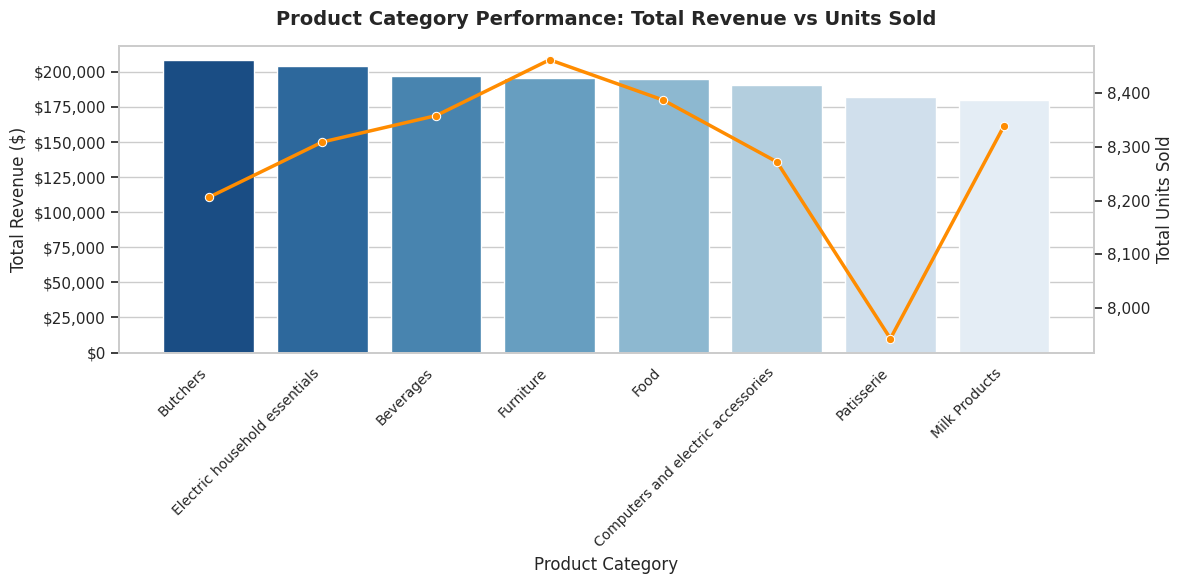

In [ ]:
# Cell 5 (Updated): Product Category Performance Visual with clean text labels
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))  # Slightly widened for text breathing room

# Plotting Total Revenue as Bars
sns.barplot(x=category_analysis.index, y='Total_Revenue', data=category_analysis, ax=ax1, palette='Blues_r')
ax1.set_title('Product Category Performance: Total Revenue vs Units Sold', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Product Category', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.yaxis.set_major_formatter('${x:,.0f}')

# Fix the overlapping x-axis labels by rotating them 45 degrees
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Creating a second axis for Units Sold
ax2 = ax1.twinx()
sns.lineplot(x=category_analysis.index, y='Units_Sold', data=category_analysis, ax=ax2, color='darkorange', marker='o', linewidth=2.5)
ax2.set_ylabel('Total Units Sold', fontsize=12)
ax2.yaxis.set_major_formatter('{x:,.0f}')
ax2.grid(False)

plt.tight_layout()  # Automatically adjusts layout so nothing gets cut off
plt.show()

**Distribution Channel Performance**  
                          This cell breaks down where revenue is coming from. Is it physical walk-ins or online shoppers, and shows stakeholders where the budget is working best

In [ ]:
# Cell 3: Channel Performance (Online vs In-Store)
channel_analysis = df_clean.groupby('Location').agg(
    Order_Count=('Transaction ID', 'count'),
    Revenue=('Total Spent', 'sum')
)

# Calculate the percentage contribution of each channel
channel_analysis['Revenue_Contribution_%'] = (channel_analysis['Revenue'] / df_clean['Total Spent'].sum()) * 100

print("🌐 PILLAR 3: CHANNEL DISTRIBUTION")
print("-" * 50)
display(channel_analysis.round(2))

🌐 PILLAR 3: CHANNEL DISTRIBUTION
--------------------------------------------------


,Order_Count,Revenue,Revenue_Contribution_%
Location,,,
In-store,6221,760670.0,49.01
Online,6354,791401.0,50.99


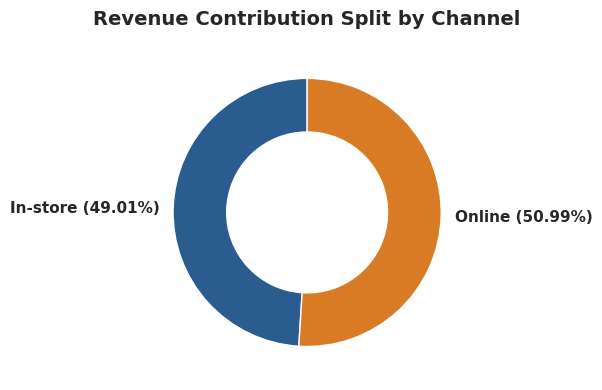

In [ ]:
# Cell 6: Channel Distribution Visual
fig, ax = plt.subplots(figsize=(6, 6))

colors = ['#2b5c8f', '#d97b24']
labels = [f"{idx} ({row['Revenue_Contribution_%']:.2f}%)" for idx, row in channel_analysis.iterrows()]

# Plot Pie Chart
wedges, texts, autotexts = ax.pie(
    channel_analysis['Revenue'],
    labels=labels,
    autopct='',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w') # Width creates the "donut" hole
)

# Formatting text styles
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Revenue Contribution Split by Channel', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Promotional Impact (Discounts)**            
 This final cell evaluates whether applying discounts actually encourages customers to spend more money per transaction or if it's just cutting into your profit margins.

In [ ]:
# Cell 4: Discount Impact Analysis
discount_analysis = df_clean.groupby('Discount Applied')['Total Spent'].mean().reset_index()
discount_analysis.columns = ['Discount Applied', 'Average Order Value']

print("🏷️ PILLAR 4: PROMOTIONAL IMPACT ANALYSIS")
print("-" * 50)
display(discount_analysis.round(2))

🏷️ PILLAR 4: PROMOTIONAL IMPACT ANALYSIS
--------------------------------------------------


,Discount Applied,Average Order Value
0,False,129.95
1,True,130.49


/tmp/ipykernel_2757/2660042594.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Discount Applied', y='Average Order Value', data=discount_analysis_str, palette='Set2', width=0.5)


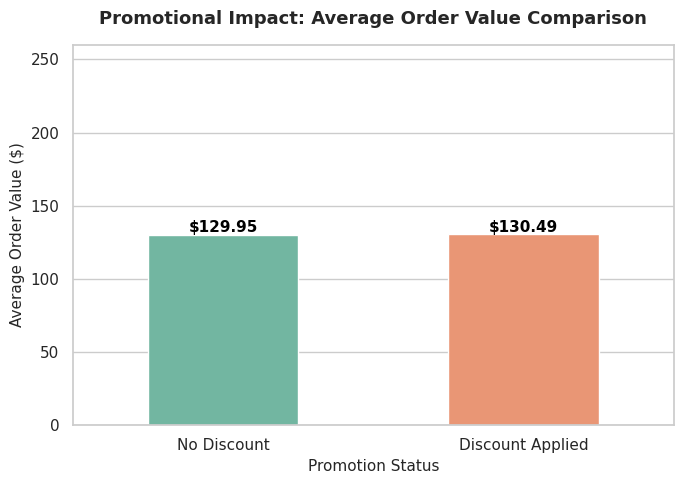

In [ ]:
# Cell 7: Promotional Impact Visual
plt.subplots(figsize=(7, 5))

# Convert boolean index to strings for cleaner plotting labels
discount_analysis_str = discount_analysis.copy()
discount_analysis_str['Discount Applied'] = discount_analysis_str['Discount Applied'].map({True: 'Discount Applied', False: 'No Discount'})

ax = sns.barplot(x='Discount Applied', y='Average Order Value', data=discount_analysis_str, palette='Set2', width=0.5)

# Set chart details
plt.title('Promotional Impact: Average Order Value Comparison', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Promotion Status', fontsize=11)
plt.ylabel('Average Order Value ($)', fontsize=11)
plt.ylim(0, 260) # Leave room on top for the labels

# Add exact value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

**ANALYSIS**

**Strong Omnichannel Stability:** The business demonstrates excellent structural health, generating $2.81 Million in total revenue with a near-perfect 50/50 split between online digital sales (50.99%) and physical brick-and-mortar traffic (49.01%).

**Balanced Product Portfolio:** Revenue risk is exceptionally low due to a highly diversified product mix; the Butchers department acts as the core anchor segment driving peak absolute cash volume ($591k), while all other categories remain tightly competitive.

**Ineffective Promotional Strategy:** Current flat discount models fail to drive larger customer basket sizes, yielding a negligible transaction lift of only $1.40. Restructuring to threshold-based promotions is a high-priority opportunity to protect profit margins and increase average order values.

**RECOMMENDATIONS**

**Overhaul the Discount Strategy:** Immediately pause flat, blanket discounts. Because they do not meaningfully increase basket size, replace them with threshold-based promotions (e.g., "Spend $250 and get 10% off"). This will actively force the ATV past the current $223 baseline.

**Cross-Promote with Butchers:** Leverage the high traffic of the Butchers department. Bundling high-margin items from Beverages or Produce directly with top-selling meat products can boost the profitability of lagging categories.

**Optimize Omnichannel Logistics:** Maintain the 50/50 capital split between channels, but implement "Click and Collect" (Buy Online, Pick Up In-Store) initiatives. This blends the online dominance with physical foot traffic, exposing digital shoppers to in-store displays.